In [2]:
require(data.table)
require(tidyverse)
require(phyloseq)
require(ggplot2)
require(RColorBrewer)
require(metacoder)
require(vegan)
require(DESeq2)

## phyloseq cleanup

In [7]:
ps<-readRDS(file = "/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_16S_outputs/ps_16S.rds")
#removing any taxa that don't show up in any samples to speed up the process
ps

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 268938 taxa and 470 samples ]
sample_data() Sample Data:       [ 470 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 268938 taxa by 6 taxonomic ranks ]

In [8]:
# remove low read counts
ps_high <- prune_samples(sample_sums(ps) >= 10000, ps)
#isolate just bacteria
ps_bac=subset_taxa(ps_high, Kingdom=="Bacteria")
#remove chloroplast order
ps_nochlo=subset_taxa(ps_bac, Order!="Chloroplast")
#remove mitochondria family
ps_nomit=subset_taxa(ps_nochlo, Family!="Mitochondria")
ps_nomit

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46684 taxa and 467 samples ]
sample_data() Sample Data:       [ 467 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 46684 taxa by 6 taxonomic ranks ]

## hmm what is happening here? I have allegedly already pruned the taxa that don't show up
- when I do not prune_taxa at first I still end up with the same 46,460

In [9]:
#removing any taxa that don't show up in any samples to speed up the process
ps_prune <- prune_taxa(taxa_sums(ps_nomit) > 0, ps_nomit)
ps_prune

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46460 taxa and 467 samples ]
sample_data() Sample Data:       [ 467 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 46460 taxa by 6 taxonomic ranks ]

In [10]:
#normalizing ps by converting rawcounts into relative abundances
#so samples with more reads wont be over represented
#using ps bc only to the count data (OTU table), while preserving the rest of the object
ps_norm = transform_sample_counts(ps_prune, function(x) 1E6 * x / sum(x))

## convert the sample_data() within a phyloseq object to a vegan compatible data object

In [11]:
# 2. reorder MonthYear as a factor in chronological order
sample_data(ps_norm)$Month_year <- factor(sample_data(ps_norm)$Month_year,levels = c("Jun 2019","May 2022","Oct 2022", "Dec 2022", "Sep 2023","Nov 2023","Dec 2023","Jan 2024","Feb 2024","Apr 2024","Jun 2024","Aug 2024"))


In [12]:
pssd2veg <- function(ps_norm) {
  sd_nomit <- sample_data(ps_norm)
  return(as(sd_nomit,"data.frame"))
}
#using phyloseq nmds plot no chloroplast
sample_nomit <- pssd2veg(ps_norm)

sample_nomit <- as.data.frame(sample_data(ps_norm))
#save sammple names as a column so tidy doesn't get rid of it during filtering
sample_nomit$SampleID <- rownames(sample_nomit)

## new repeated colonies only dataframe

In [15]:
# Return names which have more than one row of data
# Now filter
colonies <- sample_nomit %>%
  group_by(colony) %>%
  filter(n() != 1) %>%
  ungroup()

#difference bw og and repeated colonies df
nrow(sample_nomit)
nrow(colonies)

[1] 467

[1] 455

In [16]:
#how many colonies are represented?
length(unique(colonies$colony))

[1] 68

In [17]:
head(colonies)

Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted,SampleID
<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>,<chr>
Diseased_Tissue,1_3,1_22_2025,Diseased,SSID,May 2022,1,CBC30N,2022-05-21,052022_BEL_CBC_T1_2_SSID
Healthy,1_13,1_22_2025,Healthy,PAST,Sep 2023,1,CBC30N,2023-09-25,092023_BEL_CBC_T1_175_PAST
Healthy,3_70,1_23_2025,Healthy,PSTR,Feb 2024,1,Lagoon,2024-02-24,022024_BEL_CBC_T3_851_PSTR
Healthy,4_78,1_23_2025,Healthy,OFAV,Aug 2024,1,Curlew,2024-08-22,082024_BEL_CBC_T4_1609_OFAV
Healthy,3_5,1_23_2025,Healthy,SSID,Dec 2023,1,Lagoon,2023-12-16,122023_BEL_CBC_T3_526_SSID
Bleached_Tissue,4_76,1_23_2025,CLP,MCAV,Nov 2023,1,Curlew,2023-11-13,112023_BEL_CBC_T4_399_MCAV


In [29]:
# Restore rownames
rownames(colonies) <- colonies$SampleID
#check
head(rownames(colonies))
nrow(sample_data(ps_norm))

[1] "052022_BEL_CBC_T1_2_SSID"    "092023_BEL_CBC_T1_175_PAST" 
[3] "022024_BEL_CBC_T3_851_PSTR"  "082024_BEL_CBC_T4_1609_OFAV"
[5] "122023_BEL_CBC_T3_526_SSID"  "112023_BEL_CBC_T4_399_MCAV"

[1] 467

In [30]:
head(colonies)

,Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted,SampleID
,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>,<chr>
052022_BEL_CBC_T1_2_SSID,Diseased_Tissue,1_3,1_22_2025,Diseased,SSID,May 2022,1,CBC30N,2022-05-21,052022_BEL_CBC_T1_2_SSID
092023_BEL_CBC_T1_175_PAST,Healthy,1_13,1_22_2025,Healthy,PAST,Sep 2023,1,CBC30N,2023-09-25,092023_BEL_CBC_T1_175_PAST
022024_BEL_CBC_T3_851_PSTR,Healthy,3_70,1_23_2025,Healthy,PSTR,Feb 2024,1,Lagoon,2024-02-24,022024_BEL_CBC_T3_851_PSTR
082024_BEL_CBC_T4_1609_OFAV,Healthy,4_78,1_23_2025,Healthy,OFAV,Aug 2024,1,Curlew,2024-08-22,082024_BEL_CBC_T4_1609_OFAV
122023_BEL_CBC_T3_526_SSID,Healthy,3_5,1_23_2025,Healthy,SSID,Dec 2023,1,Lagoon,2023-12-16,122023_BEL_CBC_T3_526_SSID
112023_BEL_CBC_T4_399_MCAV,Bleached_Tissue,4_76,1_23_2025,CLP,MCAV,Nov 2023,1,Curlew,2023-11-13,112023_BEL_CBC_T4_399_MCAV


In [31]:
colonies <- as.data.frame(colonies)
class(colonies)

[1] "data.frame"

## create a new phyloseq object with colonies dataframe

In [32]:
keep_samples <- rownames(colonies)
length(keep_samples)
#how many of the values in keep_samples exist in ps_norm
sum(keep_samples %in% sample_names(ps_norm))  # Should be 455

[1] 455

[1] 455

In [33]:
head(sample_names(ps_norm))
head(keep_samples)

[1] "052022_BEL_CBC_T1_2_SSID"    "092023_BEL_CBC_T1_175_PAST" 
[3] "022024_BEL_CBC_T3_851_PSTR"  "082024_BEL_CBC_T4_1609_OFAV"
[5] "122023_BEL_CBC_T3_526_SSID"  "112023_BEL_CBC_T4_399_MCAV"

[1] "052022_BEL_CBC_T1_2_SSID"    "092023_BEL_CBC_T1_175_PAST" 
[3] "022024_BEL_CBC_T3_851_PSTR"  "082024_BEL_CBC_T4_1609_OFAV"
[5] "122023_BEL_CBC_T3_526_SSID"  "112023_BEL_CBC_T4_399_MCAV"

In [34]:
# Prune to keep only those samples
ps_col <- prune_samples(sample_names(ps_norm) %in% keep_samples, ps_norm)
     

In [35]:
## check up on ps_col
class(ps_col)
nrow(sample_data(ps_col))

all(rownames(colonies) %in% sample_names(ps_col))

[1] "phyloseq"
attr(,"package")
[1] "phyloseq"

[1] 455

[1] TRUE

In [36]:
ps_col

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46460 taxa and 455 samples ]
sample_data() Sample Data:       [ 455 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 46460 taxa by 6 taxonomic ranks ]

In [37]:
head(sample_data(ps_col))

,Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted
,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>
052022_BEL_CBC_T1_2_SSID,Diseased_Tissue,1_3,1_22_2025,Diseased,SSID,May 2022,1,CBC30N,2022-05-21
092023_BEL_CBC_T1_175_PAST,Healthy,1_13,1_22_2025,Healthy,PAST,Sep 2023,1,CBC30N,2023-09-25
022024_BEL_CBC_T3_851_PSTR,Healthy,3_70,1_23_2025,Healthy,PSTR,Feb 2024,1,Lagoon,2024-02-24
082024_BEL_CBC_T4_1609_OFAV,Healthy,4_78,1_23_2025,Healthy,OFAV,Aug 2024,1,Curlew,2024-08-22
122023_BEL_CBC_T3_526_SSID,Healthy,3_5,1_23_2025,Healthy,SSID,Dec 2023,1,Lagoon,2023-12-16
112023_BEL_CBC_T4_399_MCAV,Bleached_Tissue,4_76,1_23_2025,CLP,MCAV,Nov 2023,1,Curlew,2023-11-13


In [38]:
nrow(sample_data(ps_col))

[1] 455

In [ ]:
#take the filtered metadata I just worked on — with cleaned rows, and correct sample names — and replace the old sample data in ps_clean with this cleaned version
col_clean <- phyloseq::sample_data(colonies)
sample_data(ps_col) <- col_clean
head(sample_data(ps_col))

In [39]:
# 2. reorder MonthYear as a factor in chronological order
sample_data(ps_col)$Month_year <- factor(sample_data(ps_col)$Month_year,levels = c("Jun 2019","May 2022","Oct 2022", "Dec 2022", "Sep 2023","Nov 2023","Dec 2023","Jan 2024","Feb 2024","Apr 2024","Jun 2024","Aug 2024"))


# How are the microbiomes of individual coral colonies changing overtime?
- do they recruit fewer bacteria?
- do they shift to recruiting new bacteria?

### subset by cora host species to make plots easier to read

In [41]:

#new dataframes for each species 
ps_mcav <- subset_samples(ps_col, Species == "MCAV")
ps_pstr <- subset_samples(ps_col, Species == "PSTR")
ps_ofav <- subset_samples(ps_col, Species == "OFAV")
ps_ssid <- subset_samples(ps_col, Species == "SSID")
ps_oann <- subset_samples(ps_col, Species == "OANN")
ps_past <- subset_samples(ps_col, Species == "PAST") 

In [42]:
#should add up to 455 samples
nrow(sample_data(ps_mcav))
nrow(sample_data(ps_pstr))
nrow(sample_data(ps_ofav))
nrow(sample_data(ps_oann))
nrow(sample_data(ps_ssid))
nrow(sample_data(ps_past))

[1] 132

[1] 65

[1] 62

[1] 16

[1] 84

[1] 96

In [43]:
#how many colonies? 68
table(sample_data(ps_col)[,"colony"])

colony
 1_12  1_13  1_14  1_15  1_16  1_17  1_19   1_2  1_20  1_21  1_22  1_24  1_25 
   11     4     3     3     2     3     3     9     4     8     5    12     7 
  1_3   1_4   1_5   1_6   1_8  2_28  2_30  2_52  2_55  2_56  2_57  2_59  2_60 
   13     3     2     4     4     2     3     2    11     4    11     2    11 
 2_63  2_68  2_69  2_70  2_72  2_73  2_76  2_79  2_80  2_99  3_10  3_14  3_15 
   11    11    11     3    12    11    10    10     4     9     8    10     5 
 3_17  3_18  3_19   3_2  3_20  3_21  3_22  3_24  3_28   3_3  3_33  3_34  3_38 
    3     5     2    13    11    11     3     3     3     2    11    10    10 
 3_39   3_5   3_6  3_66  3_70 4_100  4_28  4_30  4_76  4_78  4_79  4_94  4_95 
   10    11     6     7     9     3     8     9     9     9     9     2     2 
 4_96  4_97  4_98 
    2     2     9 

## family plots for each species 
- facetted by colony

In [44]:
# plot sizing
options(repr.plot.width=20, repr.plot.height=15)

In [46]:

    # how many unique family taxa are there total?
length(unique(tax_table(ps_col)[, "Family"]))


#reduce that to top 50
ps_fam=tax_glom(ps_col, taxrank= "Family")

#isolating top 50 family taxa
top50<- names(sort(taxa_sums(ps_fam), decreasing=TRUE))[1:50] 
ps_fam <- prune_taxa(top50, ps_fam) 

#confirm that it has been reduced
length(unique(tax_table(ps_fam)[, "Family"]))

[1] 469

[1] 50

In [47]:
## assigning colors 

#assigning colors
famcolors= colorRampPalette(brewer.pal(8, "Accent"))(50)

#Generate a random set of colors based on a df fam_taxa that assigns a random color to each spot in the list
fam_taxa <- unique(tax_table(ps_fam)[, "Family"])
    famcolors <- sample(famcolors, 50, length(fam_taxa))
    # naming my color palette so the random order stays the same
    famcolors<- setNames(famcolors, fam_taxa)

### past

Warning message in geom_text(aes(label = Family, fill = Family), position = position_stack(vjust = 0.5), :
“Ignoring unknown aesthetics: fill”


<Guides[1] ggproto object>

colour : <GuideLegend>

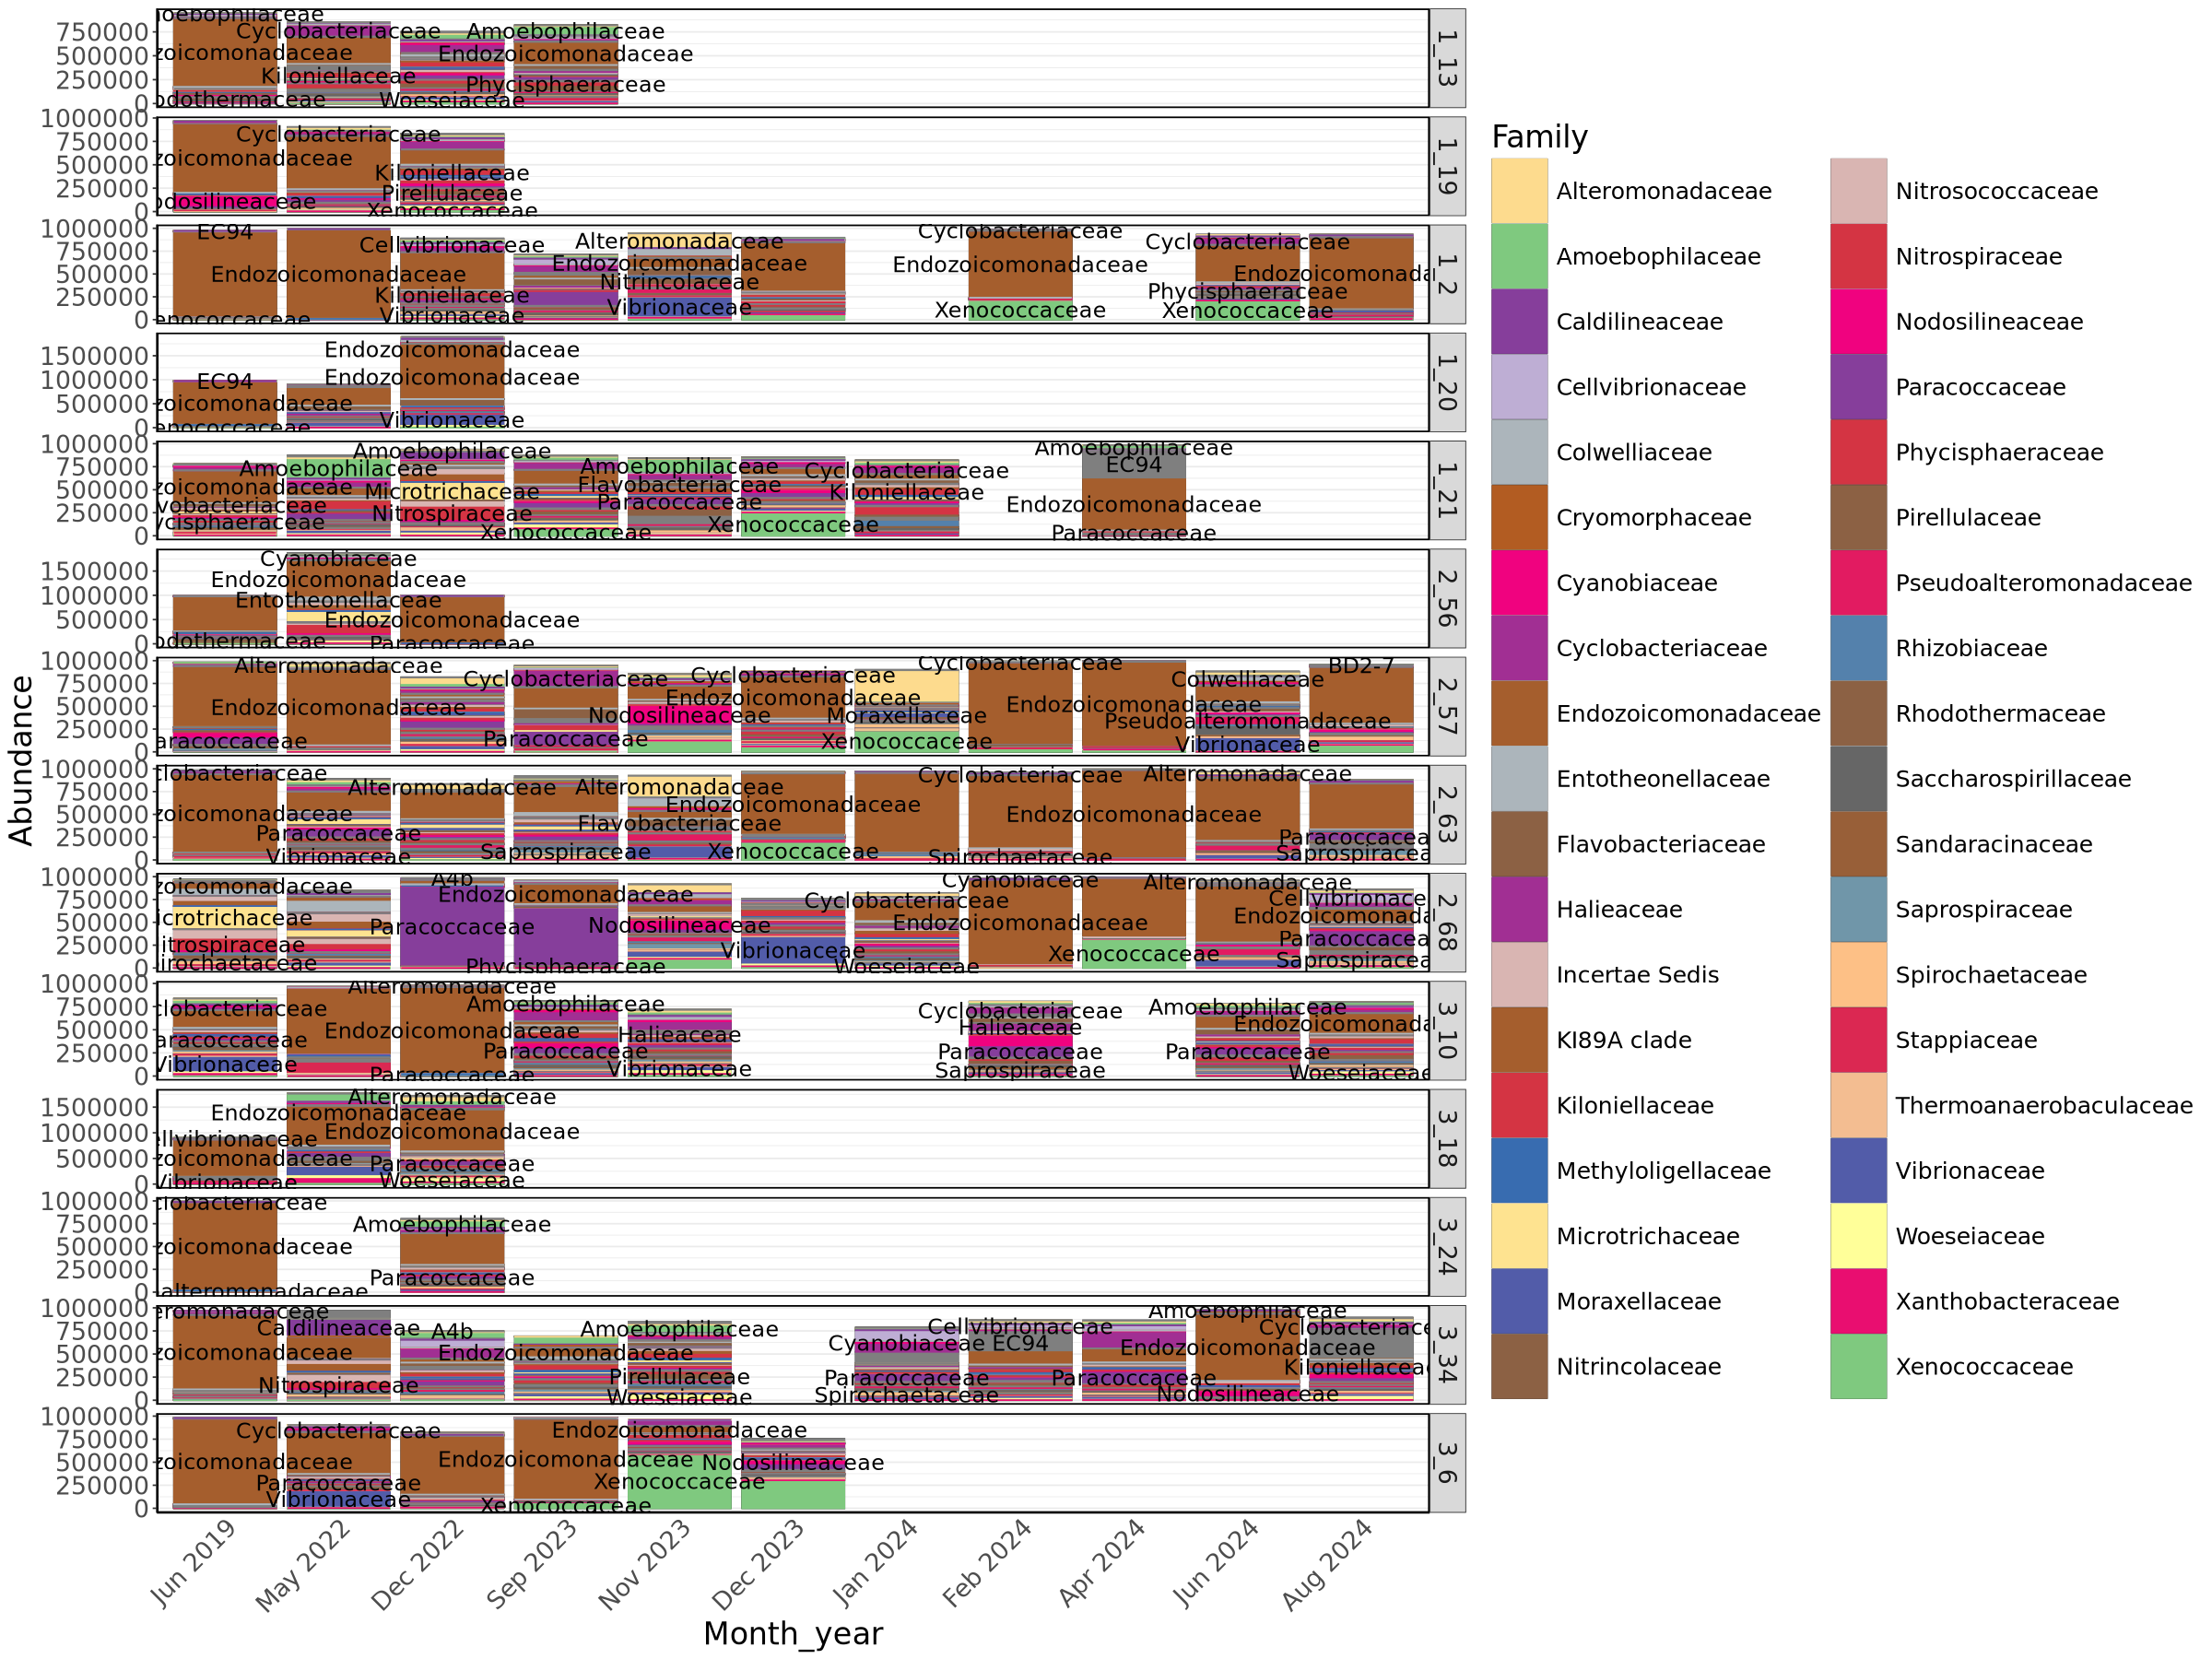

In [49]:
ps_past=tax_glom(ps_past, taxrank= "Family")

top50_past <- names(sort(taxa_sums(ps_past), decreasing=TRUE))[1:50] 
top50_past <- prune_taxa(top50_past, ps_past) 

#plot
past <- plot_bar(top50_past, x="Month_year", fill = "Family") +
  facet_wrap(colony ~., strip.position = "right", ncol = 1, scales = "free_y") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  geom_text(aes(label = Family, fill = Family),
            position = position_stack(vjust = 0.5),
            color = "black", size = 5, check_overlap = TRUE) +
  scale_fill_manual(values = famcolors, drop = TRUE) +
  scale_color_manual(values = famcolors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 20)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
past

### pstr

Warning message in geom_text(aes(label = Family, fill = Family), position = position_stack(vjust = 0.5), :
“Ignoring unknown aesthetics: fill”


<Guides[1] ggproto object>

colour : <GuideLegend>

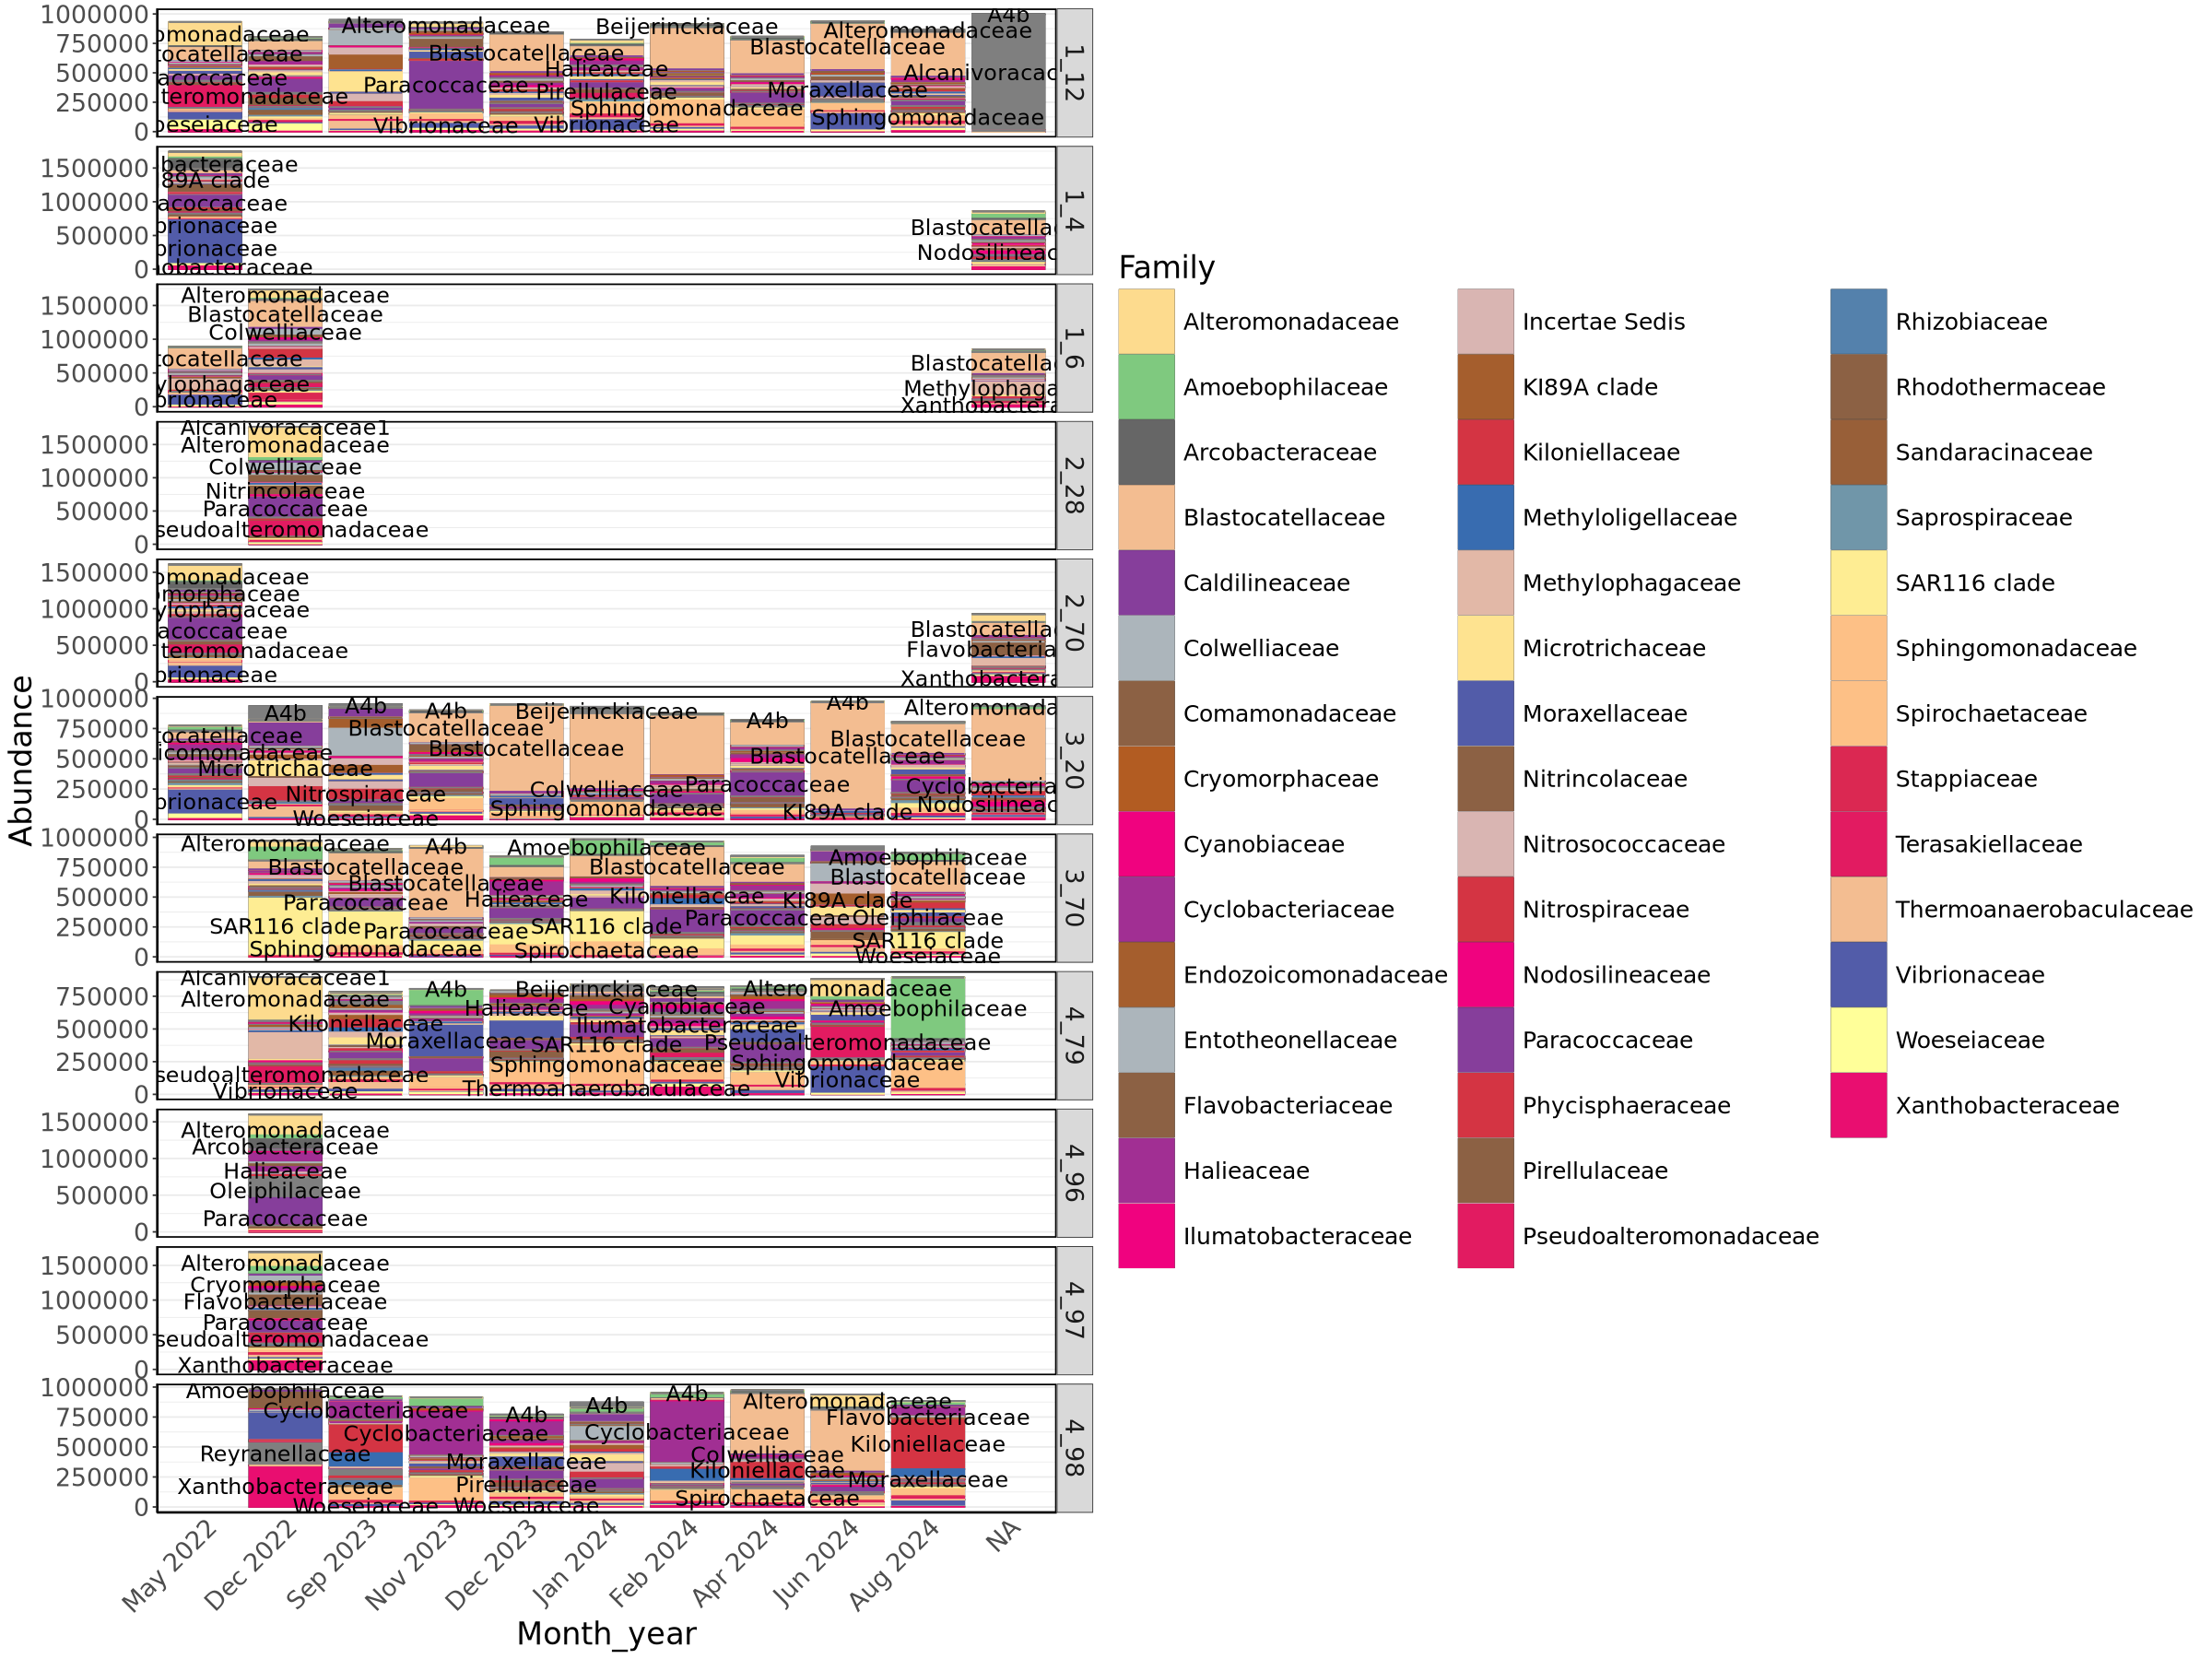

In [51]:
#reduce to top 50
fam_pstr=tax_glom(ps_pstr, taxrank= "Family")

top50_pstr <- names(sort(taxa_sums(fam_pstr), decreasing=TRUE))[1:50] 
fam_pstr <- prune_taxa(top50_pstr, fam_pstr) 

#plot
fam_pstr <- plot_bar(fam_pstr, x="Month_year", fill="Family") +
   facet_wrap(colony ~., strip.position = "right", ncol = 1, scales = "free_y") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  geom_text(aes(label = Family, fill = Family),
            position = position_stack(vjust = 0.5),
            color = "black", size = 5, check_overlap = TRUE) +
  scale_fill_manual(values = famcolors, drop = TRUE) +
  scale_color_manual(values = famcolors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 20)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
fam_pstr

### mcav

Warning message in geom_text(aes(label = Family, fill = Family), position = position_stack(vjust = 0.5), :
“Ignoring unknown aesthetics: fill”


<Guides[1] ggproto object>

colour : <GuideLegend>

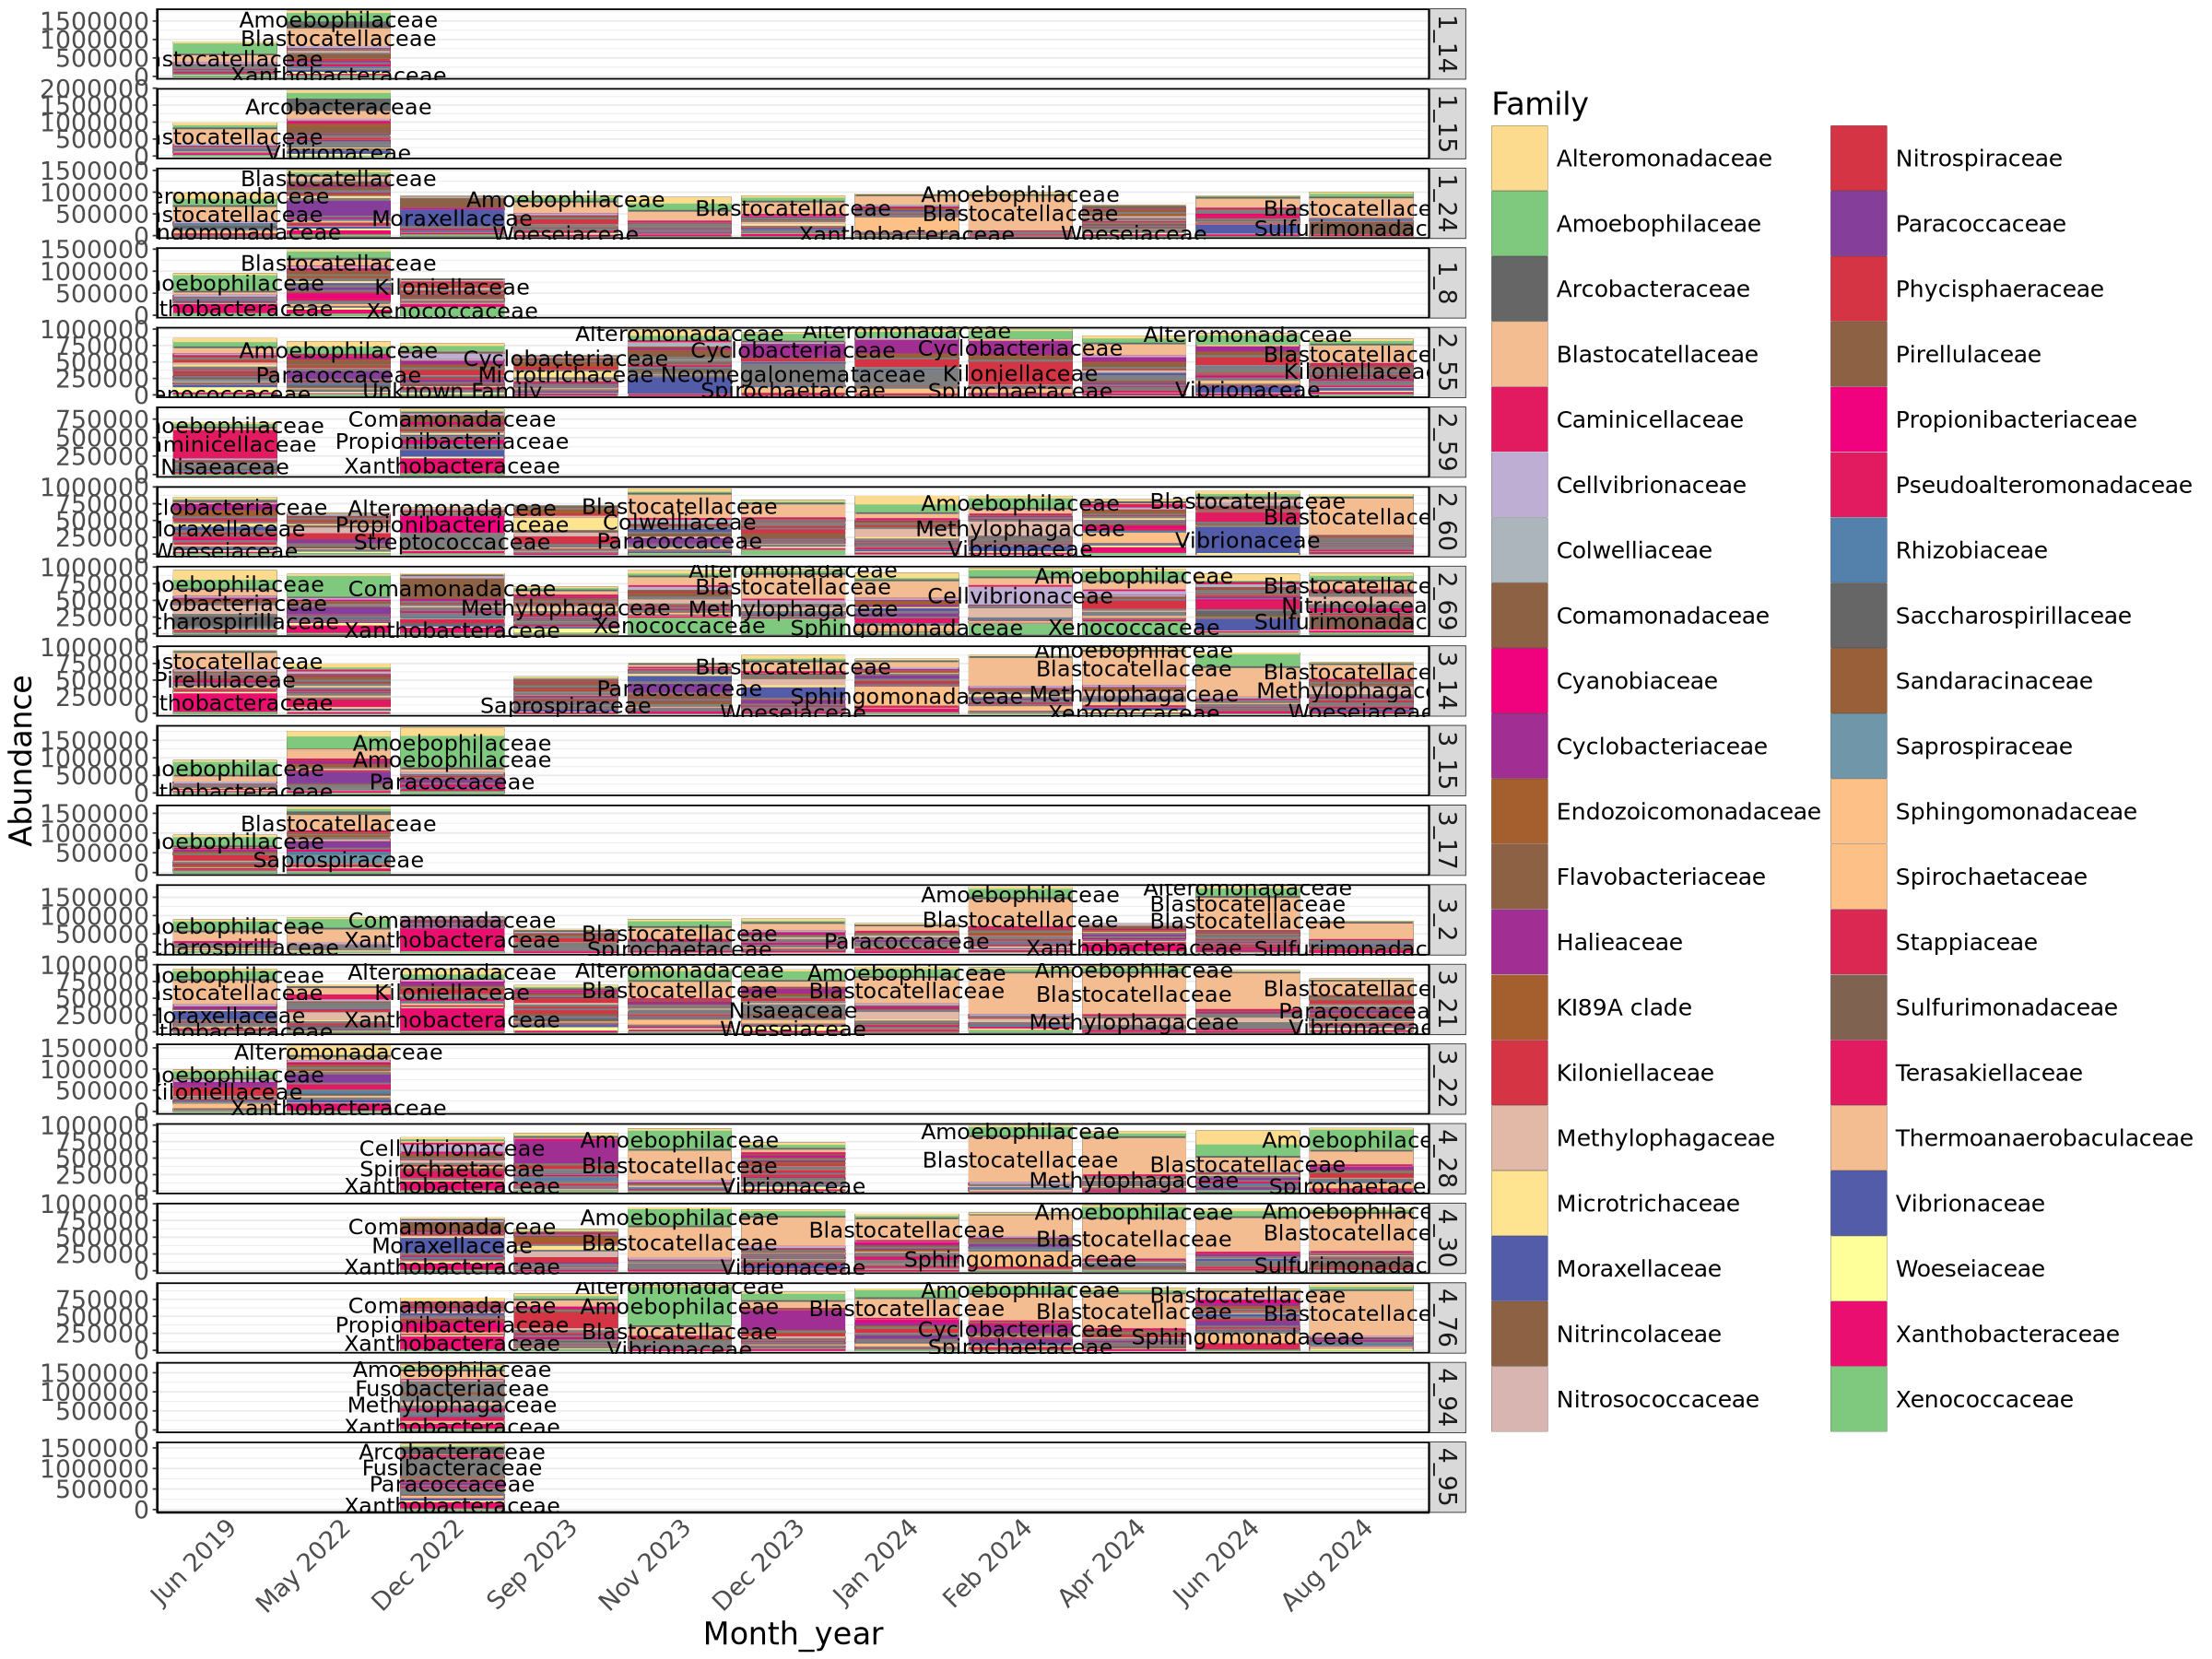

In [55]:
#reduce to top 50
fam_mcav=tax_glom(ps_mcav, taxrank= "Family")

top50_mcav <- names(sort(taxa_sums(fam_mcav), decreasing=TRUE))[1:50] 
top50_mcav <- prune_taxa(top50_mcav, fam_mcav) 

#plot
fam_mcav <- plot_bar(top50_mcav, x="Month_year", fill="Family") +
   facet_wrap(colony ~., strip.position = "right", ncol = 1, scales = "free_y") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  geom_text(aes(label = Family, fill = Family),
            position = position_stack(vjust = 0.5),
            color = "black", size = 5, check_overlap = TRUE) +
  scale_fill_manual(values = famcolors, drop = TRUE) +
  scale_color_manual(values = famcolors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 20)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
fam_mcav

# How do the microbiomes of individual colonies change with exposure to stressors like heat and disease?
- P. asteroides seem to lose their endozoic communities after bleaching, and gain them back after recovery
- 

## past health status

Warning message in geom_text(aes(label = Family, fill = Family), position = position_stack(vjust = 0.5), :
“Ignoring unknown aesthetics: fill”


<Guides[1] ggproto object>

colour : <GuideLegend>

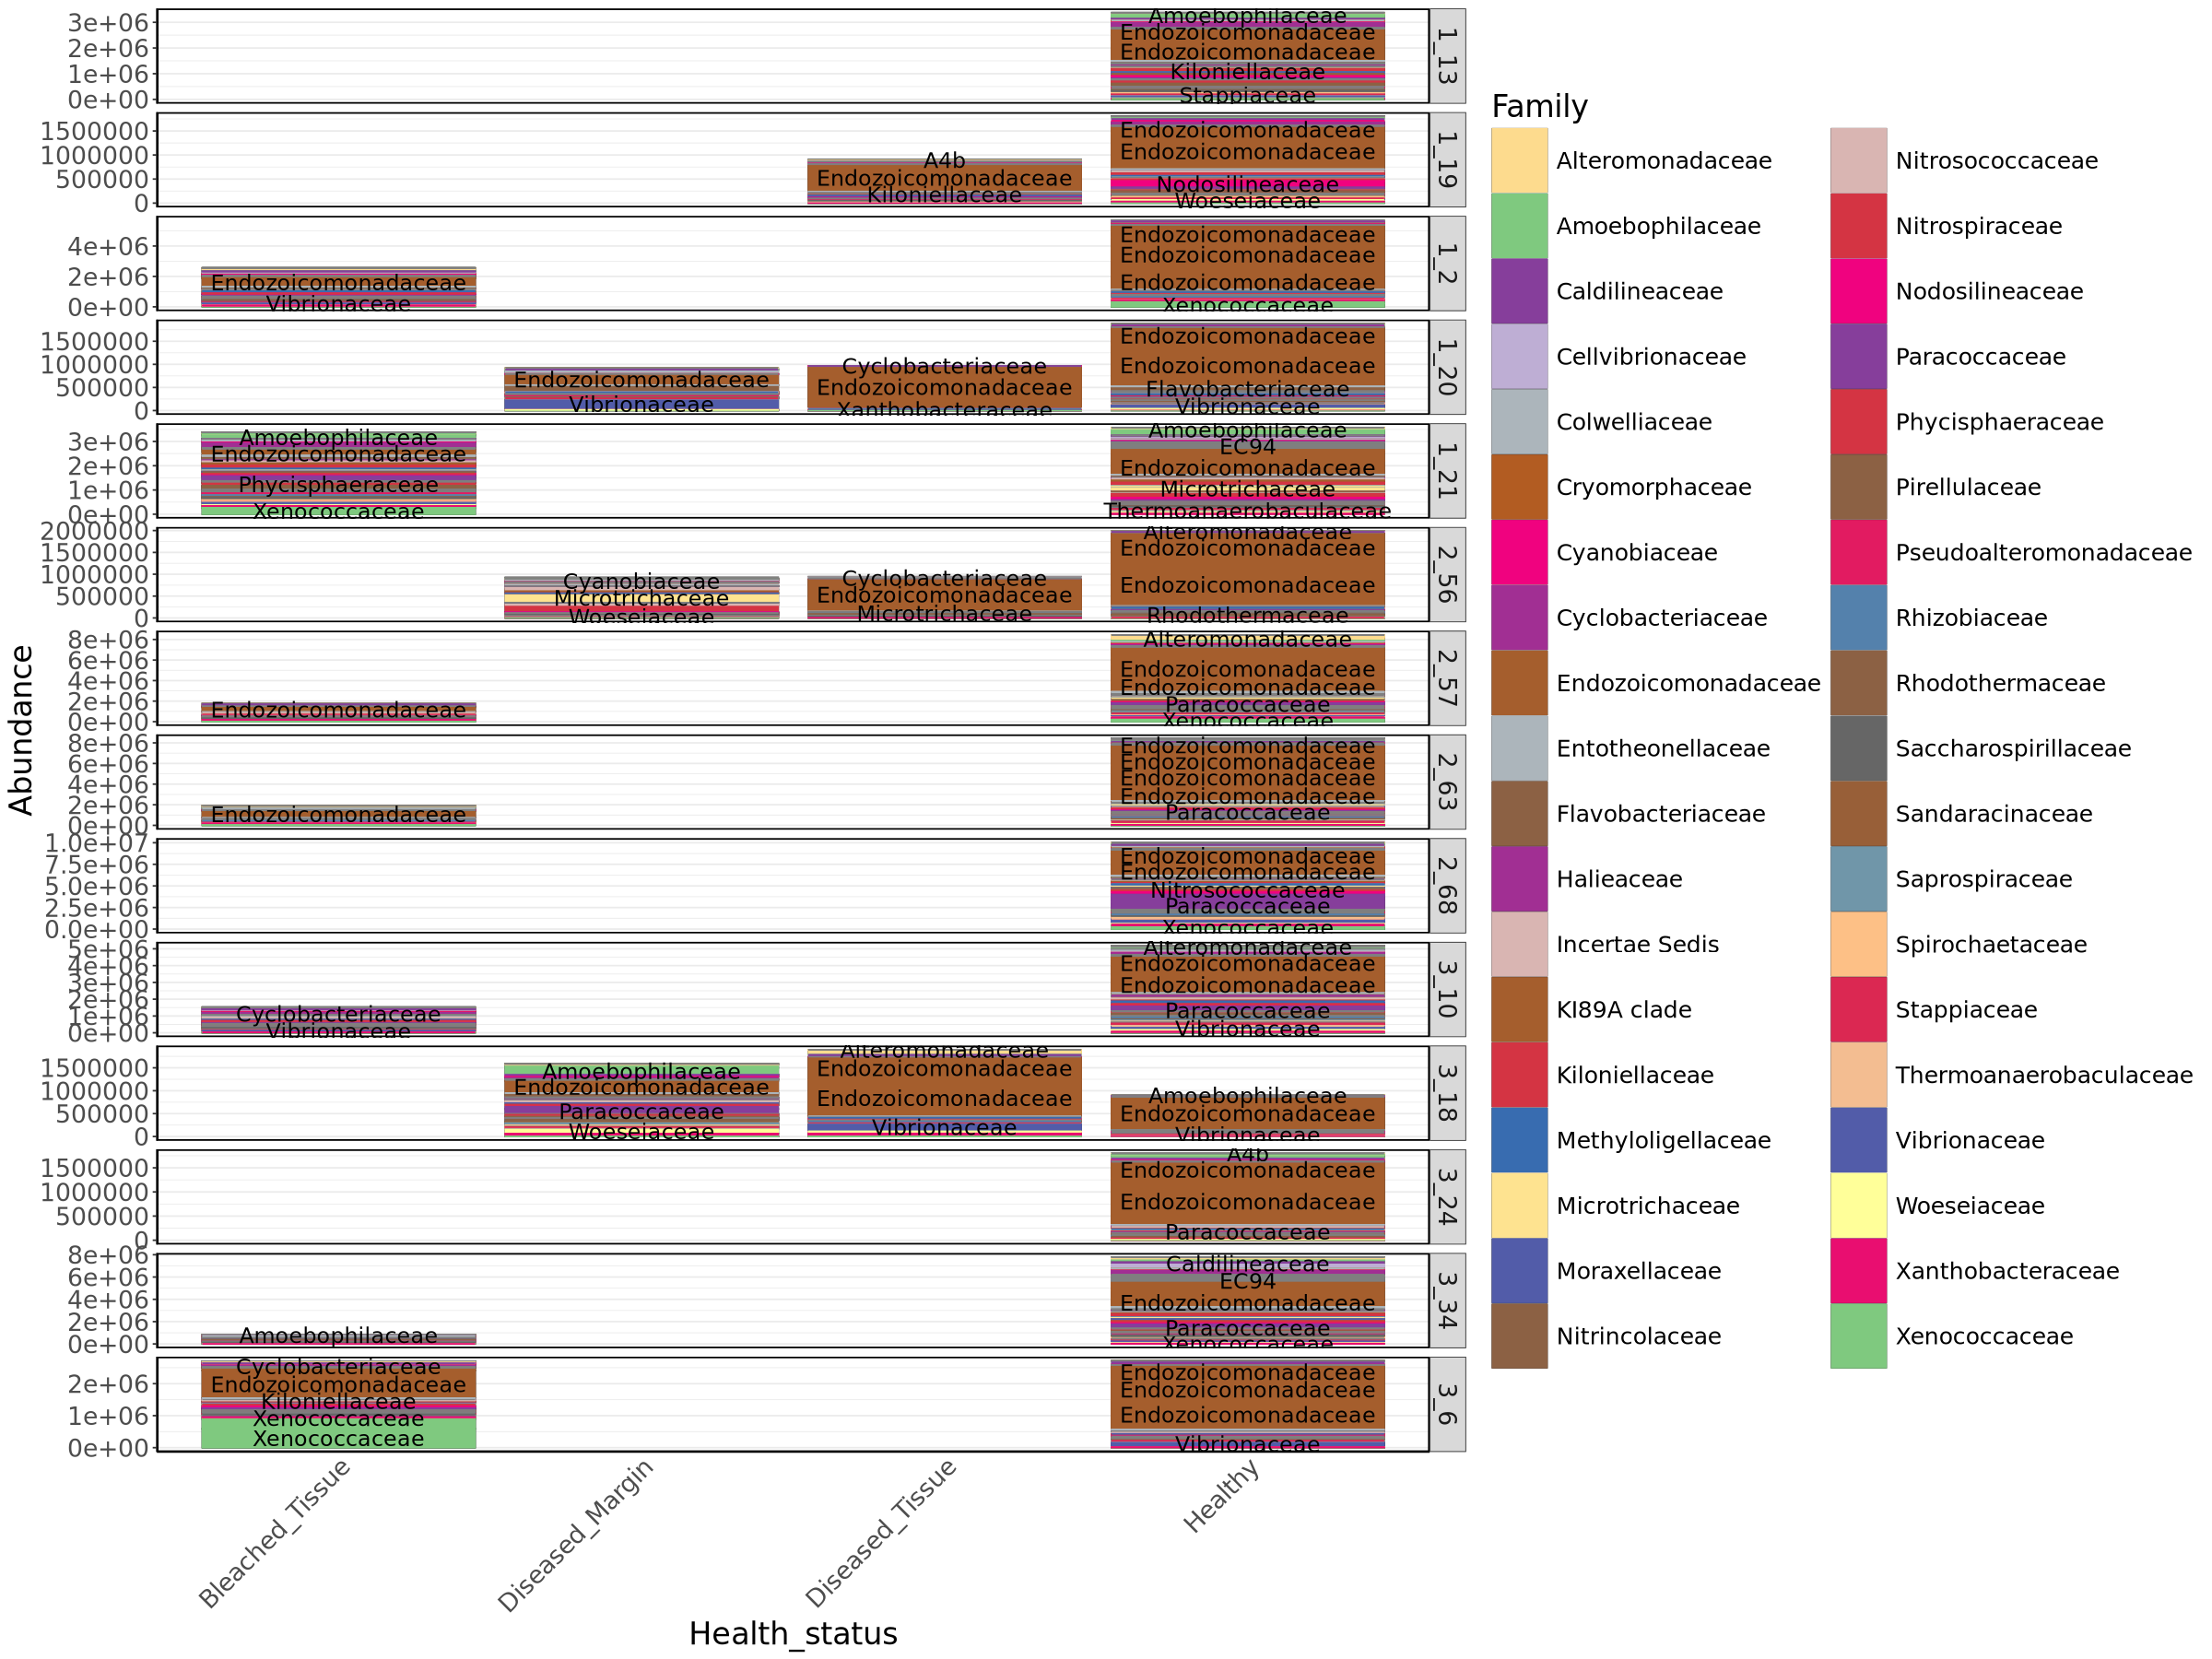

In [53]:
#plot
health_past <- plot_bar(top50_past, x="Health_status", fill="Family") +
   facet_wrap(colony ~., strip.position = "right", ncol = 1, scales = "free_y") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  geom_text(aes(label = Family, fill = Family),
            position = position_stack(vjust = 0.5),
            color = "black", size = 5, check_overlap = TRUE) +
  scale_fill_manual(values = famcolors, drop = TRUE) +
  scale_color_manual(values = famcolors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 20)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
health_past

## mcavs health status

Warning message in geom_text(aes(label = Family, fill = Family), position = position_stack(vjust = 0.5), :
“Ignoring unknown aesthetics: fill”


<Guides[1] ggproto object>

colour : <GuideLegend>

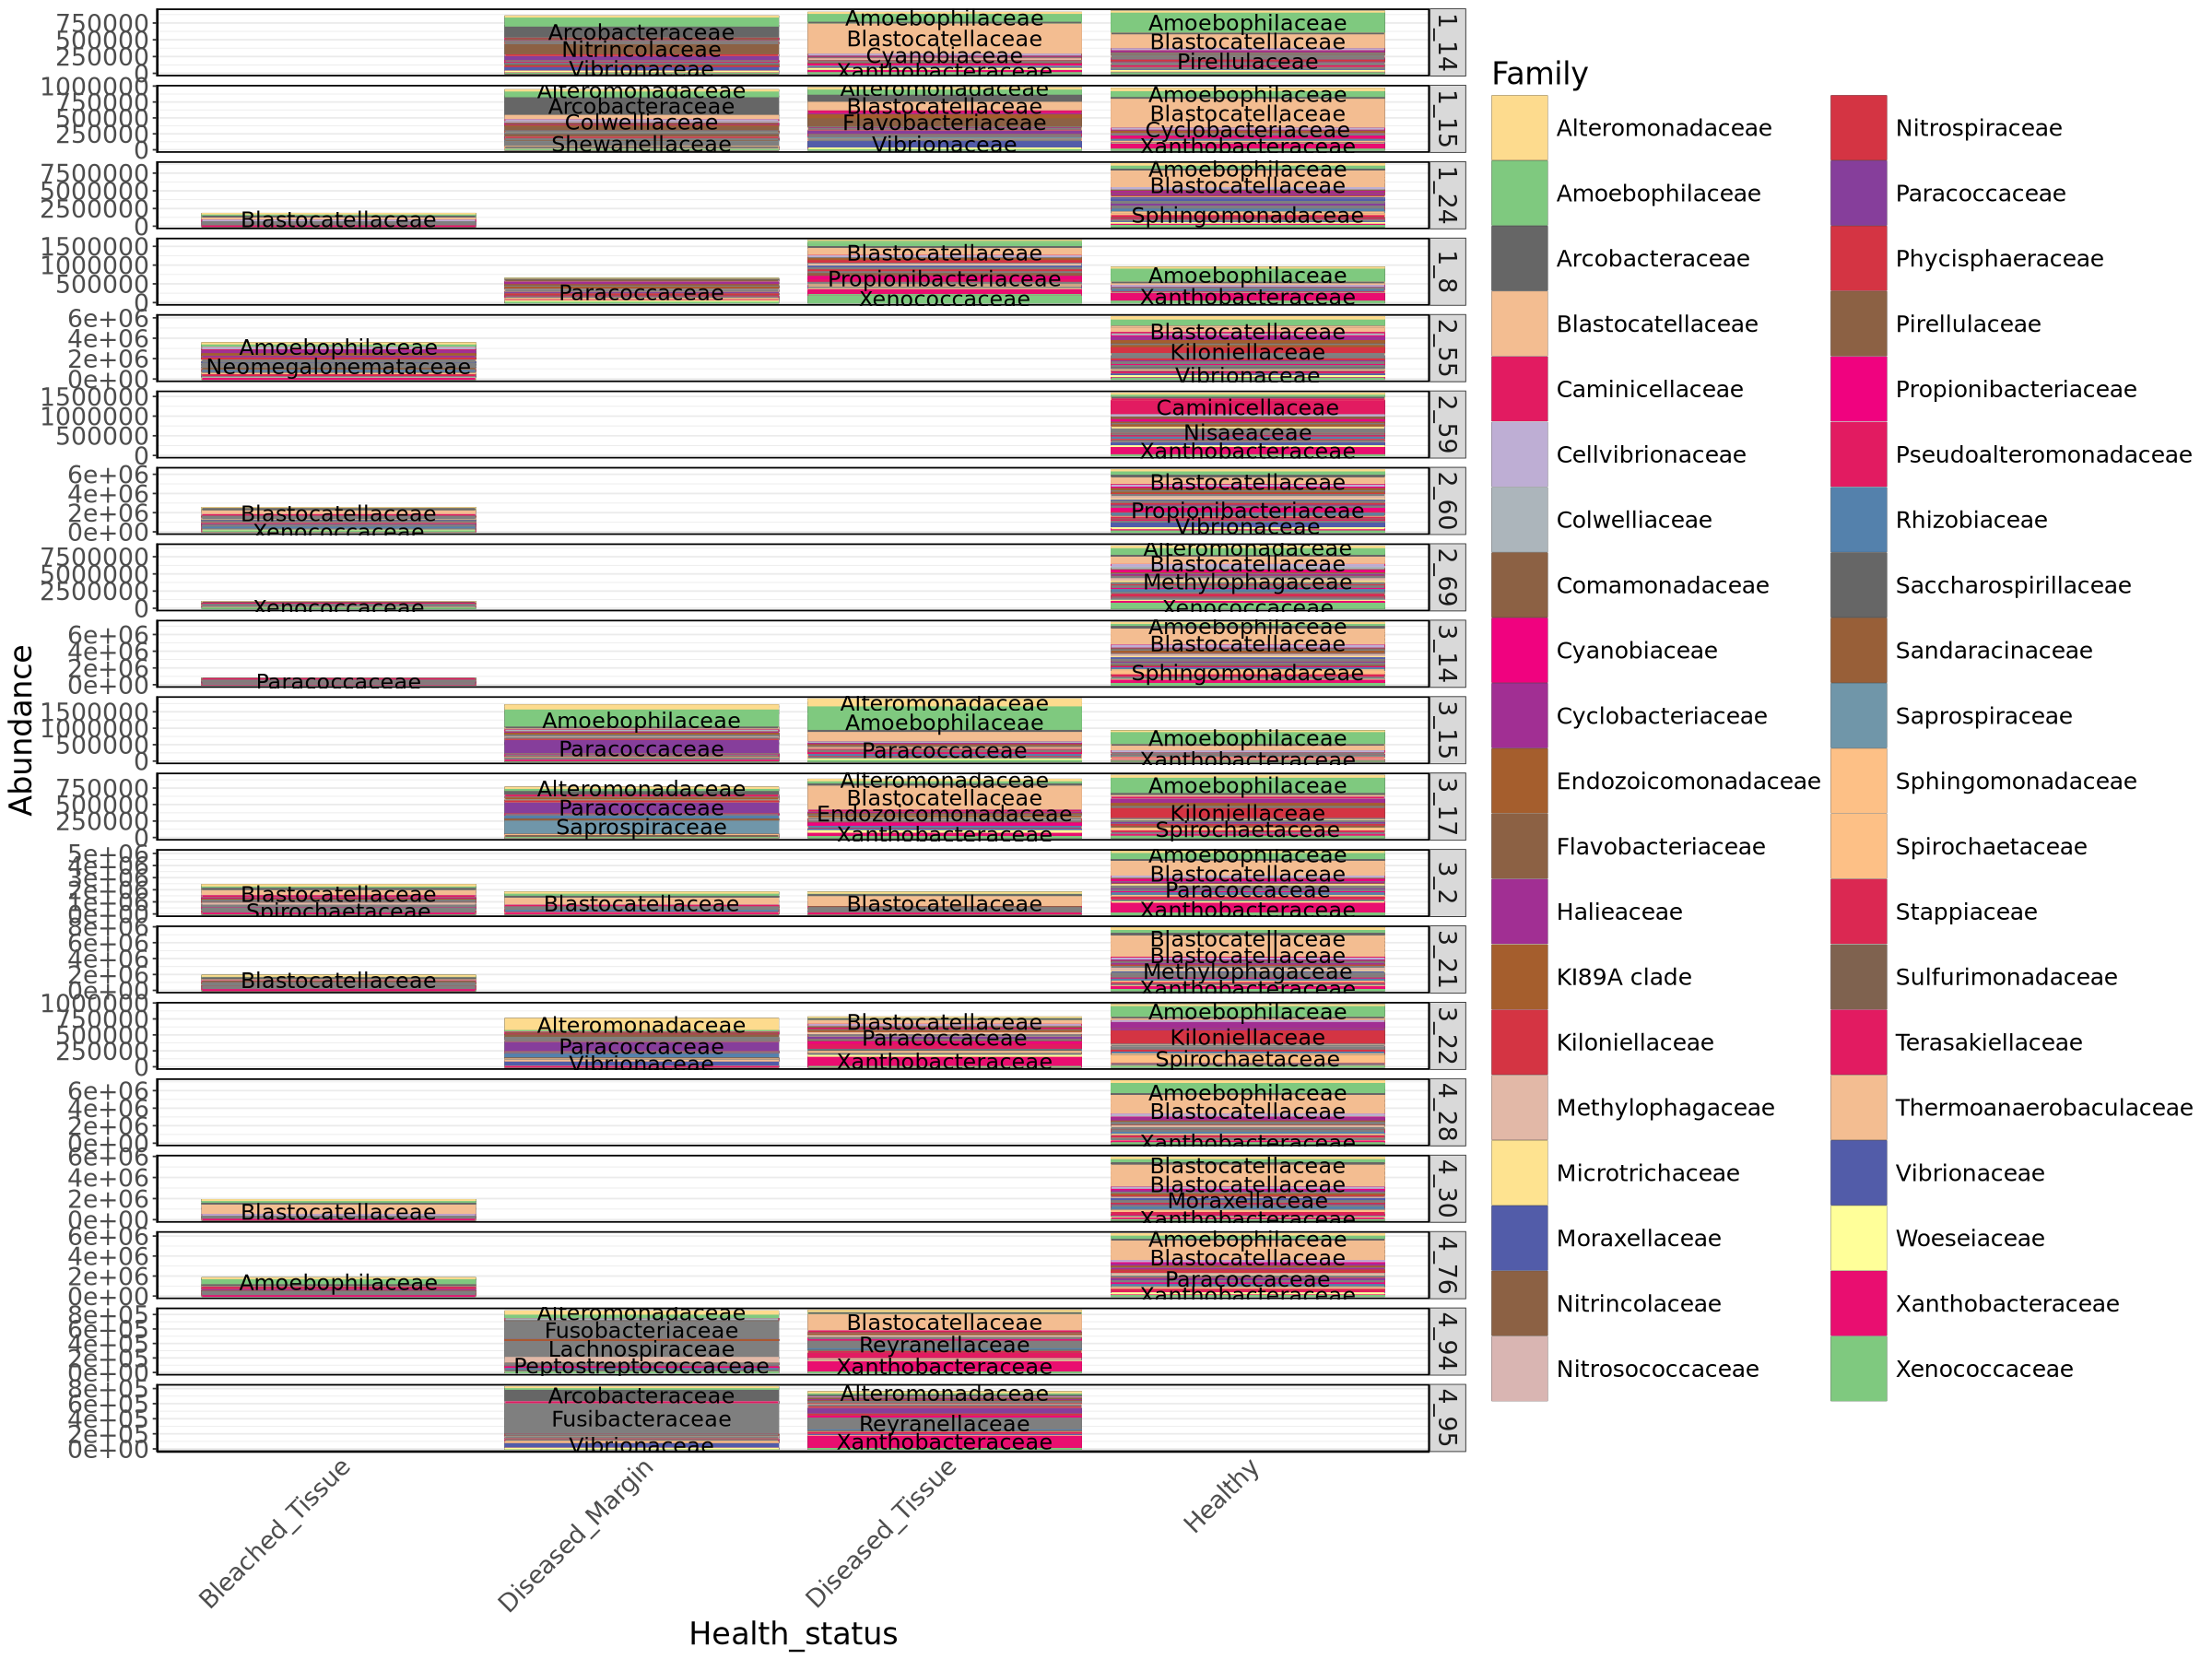

In [56]:

#plot
health_mcav <- plot_bar(top50_mcav, x="Health_status", fill="Family") +
   facet_wrap(colony ~., strip.position = "right", ncol = 1, scales = "free_y") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  geom_text(aes(label = Family, fill = Family),
            position = position_stack(vjust = 0.5),
            color = "black", size = 5, check_overlap = TRUE) +
  scale_fill_manual(values = famcolors, drop = TRUE) +
  scale_color_manual(values = famcolors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 20)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
health_mcav